
**Q1: What is the fundamental purpose of the self-attention mechanism?**
A: The self-attention mechanism's core purpose is to convert **static word embeddings into dynamic, contextual embeddings**. This allows words to have different numerical representations based on their surrounding context, solving issues where the same word (e.g., "bank") has the same static embedding despite different meanings (e.g., "money bank" vs. "river bank").

**Q2: Outline the steps of a simple, "first principles" self-attention model.**
A:
*   **Obtain Static Word Embeddings:** Initially, static word embeddings (e.g., from Word2Vec or GloVe) are generated for each word in a sentence.
*   **Calculate Similarity Scores:** To determine context, the similarity between a target word's embedding and every other word's embedding in the sentence is calculated using the **dot product**.
*   **Normalize Similarity Scores:** These raw similarity scores are then normalized using the **Softmax function**, turning them into weights that sum to one.
*   **Generate New Contextual Embedding:** Finally, these Softmax-normalized weights are used in a **weighted sum** of all word embeddings in the sentence to produce a new, dynamic, contextual embedding for the target word. This process is repeated for every word.

**Q3: What are the key advantages and limitations of this simple model?**
A:
*   **Advantage:** The entire process can be performed **in parallel** using linear algebra and matrix operations, allowing for fast computation, especially with GPUs.
*   **Limitations:**
    *   **No Learning Parameters:** It lacks learnable weights and biases, meaning it **cannot "learn" from data**.
    *   **General Contextual Embeddings:** It produces **general contextual embeddings**, which are not task-specific and may not capture nuanced meanings required for complex NLP tasks (e.g., "piece of cake" as "very easy task" vs. a literal "cake slice").
    *   **Loss of Sequential Information:** The parallel nature means it **loses information about the order or sequence of words**.

**Q4: How does the refined self-attention model, used in Transformers, improve upon the simple model?**
A: The refined model addresses the limitations by introducing **learnable parameters** in the form of Query (Q), Key (K), and Value (V) vectors. This allows for the generation of **task-specific contextual embeddings**.

**Q5: Describe the steps of the refined self-attention mechanism.**
A:
*   **Generate Query (Q), Key (K), and Value (V) Vectors:** For each static word embedding (E), three distinct vectors—Query (Q), Key (K), and Value (V)—are generated. This is done through a **linear transformation**, where the original embedding (E) is multiplied by three separate, **learnable weight matrices: Wq, Wk, and Wv**. These matrices are initially random but are **updated through backpropagation** during training, enabling the model to learn task-specific representations. The same Wq, Wk, and Wv matrices are applied to all words in the sentence.
*   **Calculate Similarity Scores:** Similarity scores are computed by taking the **dot product of the target word's Query (Q) vector** with all words' **Key (K) vectors** in the sentence.
*   **Normalize Similarity Scores:** The resulting scores are then passed through a **Softmax function** to obtain attention weights.
*   **Generate New Contextual Embedding:** Finally, the new contextual embedding for the target word is calculated as a **weighted sum of all words' Value (V) vectors**, using the Softmax-normalized attention weights.

**Q6: What are the key benefits of the refined self-attention model?**
A:
*   **Task-Specific Embeddings:** By introducing learnable parameters (Wq, Wk, Wv), the model generates **task-specific contextual embeddings** that are optimized for the particular NLP task (e.g., machine translation, sentiment analysis).
*   **Parallelization:** Similar to the simple model, this refined approach fully utilizes **parallel computation through matrix operations**, allowing for efficient and fast training on GPUs, even with large datasets.

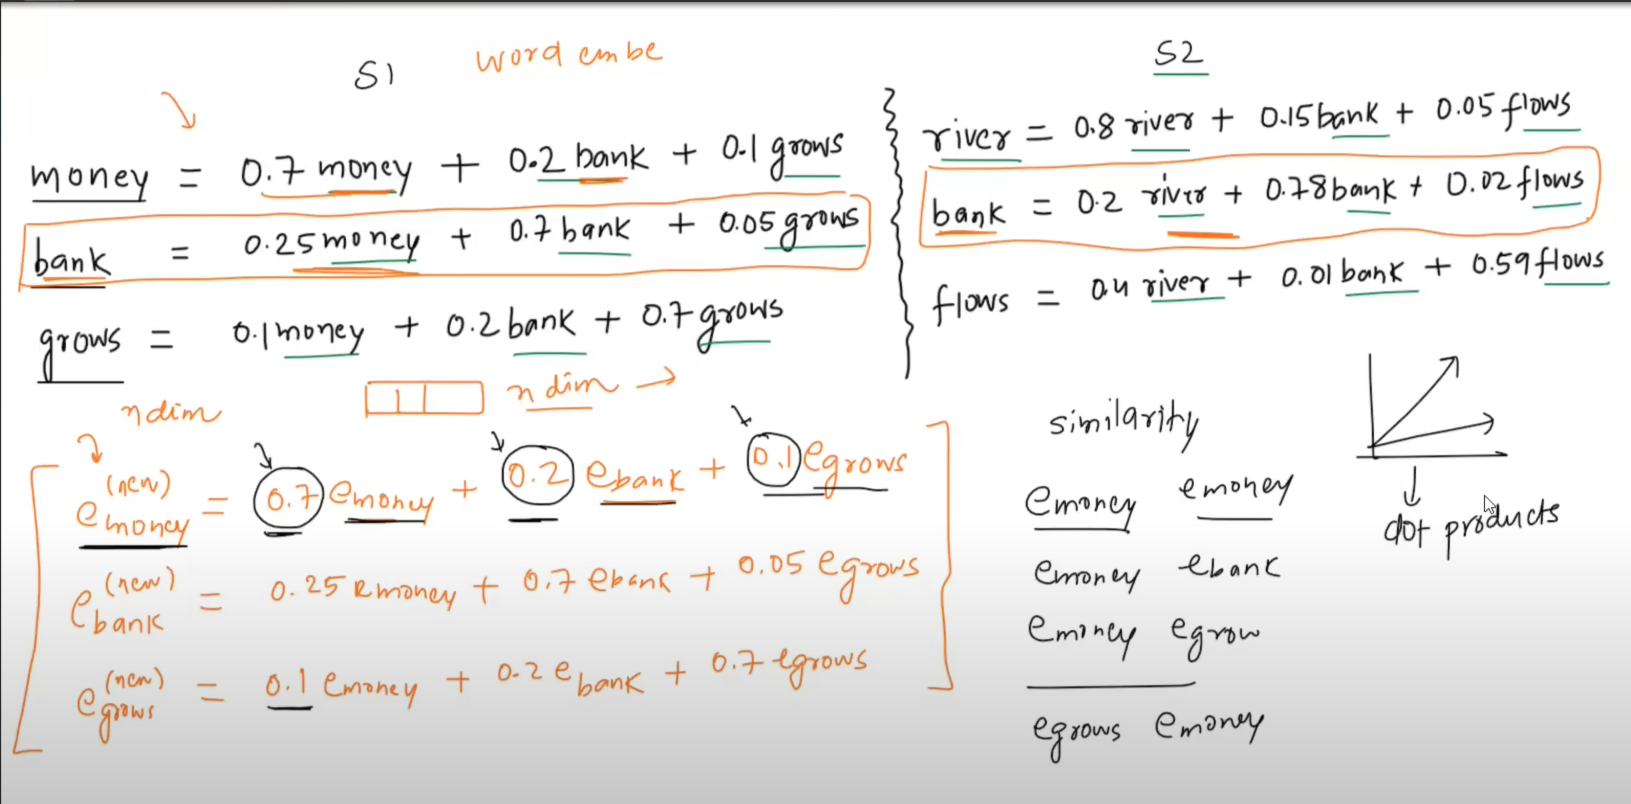

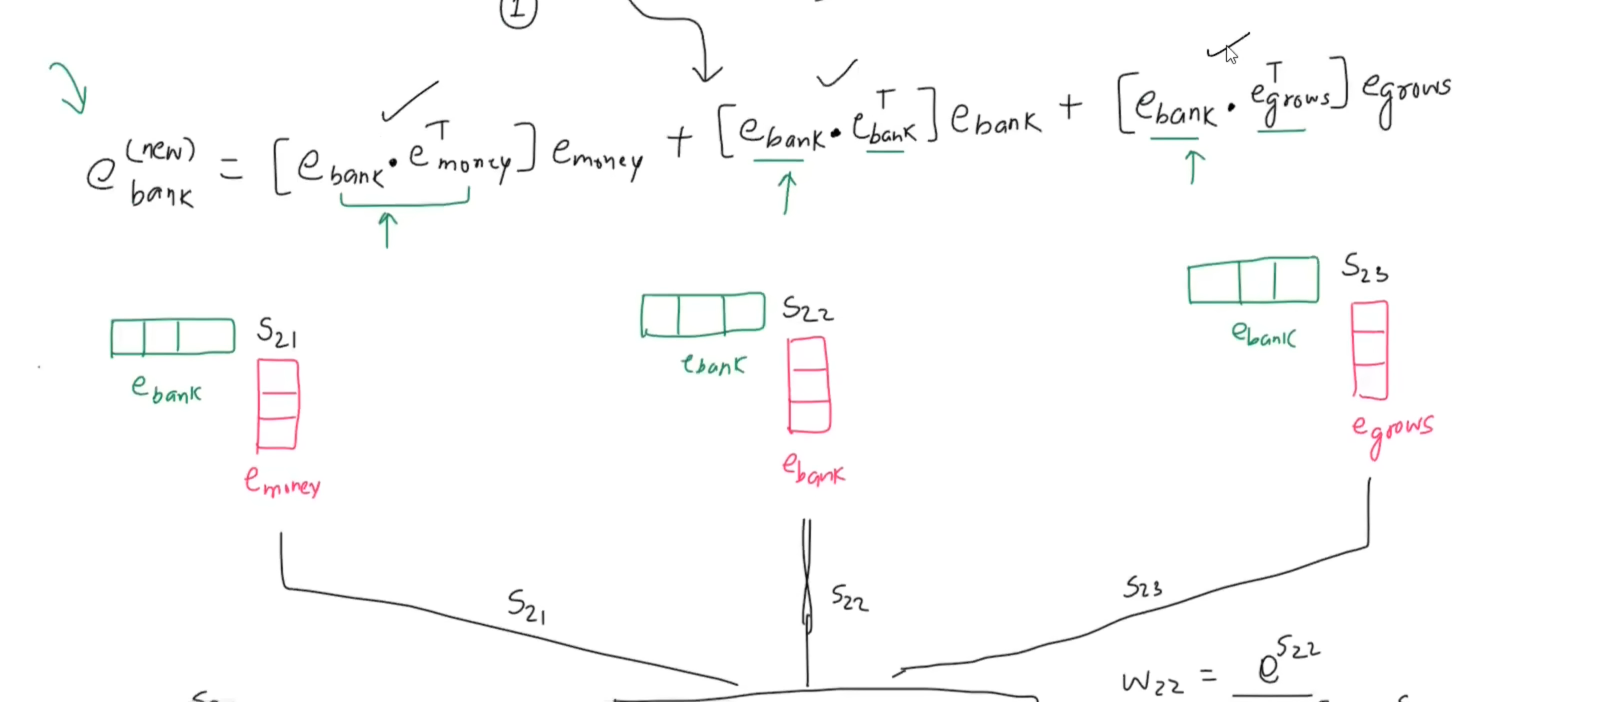

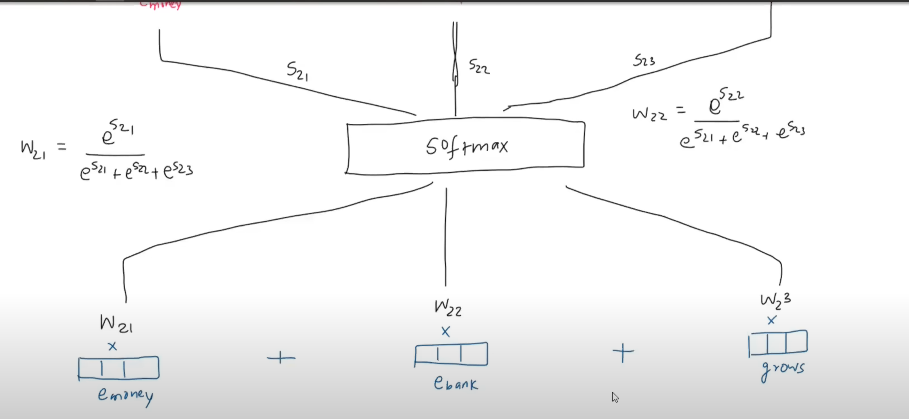

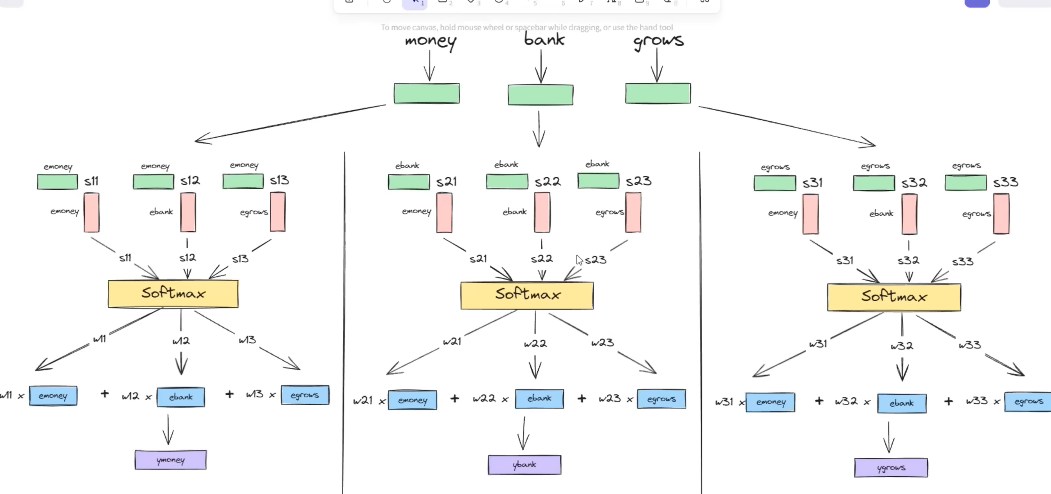

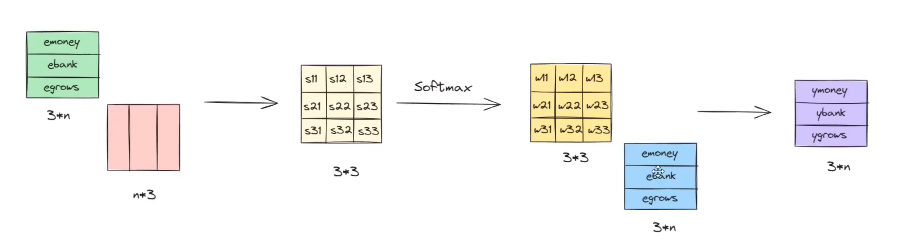

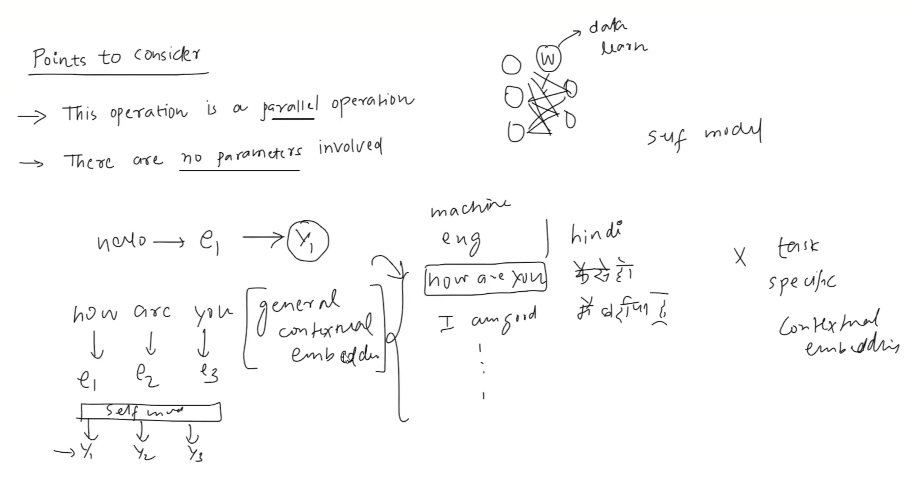

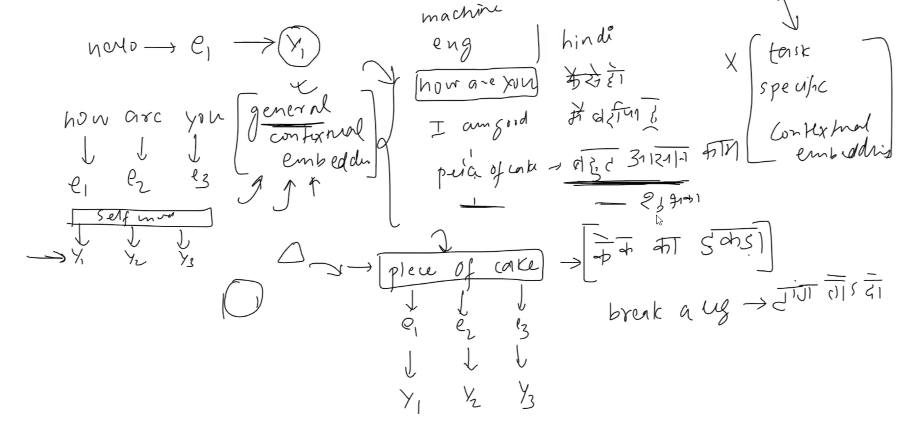

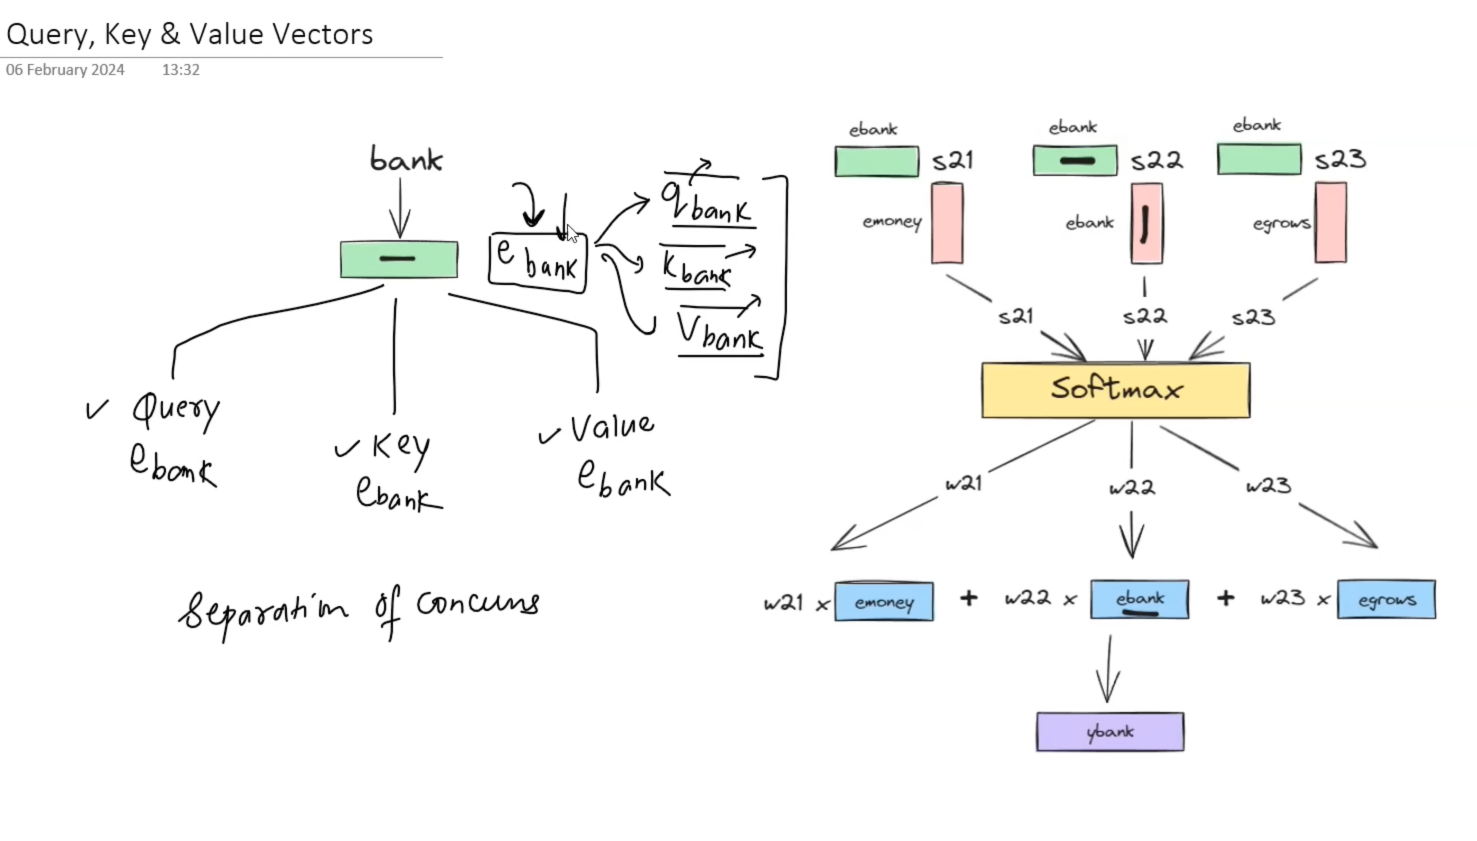

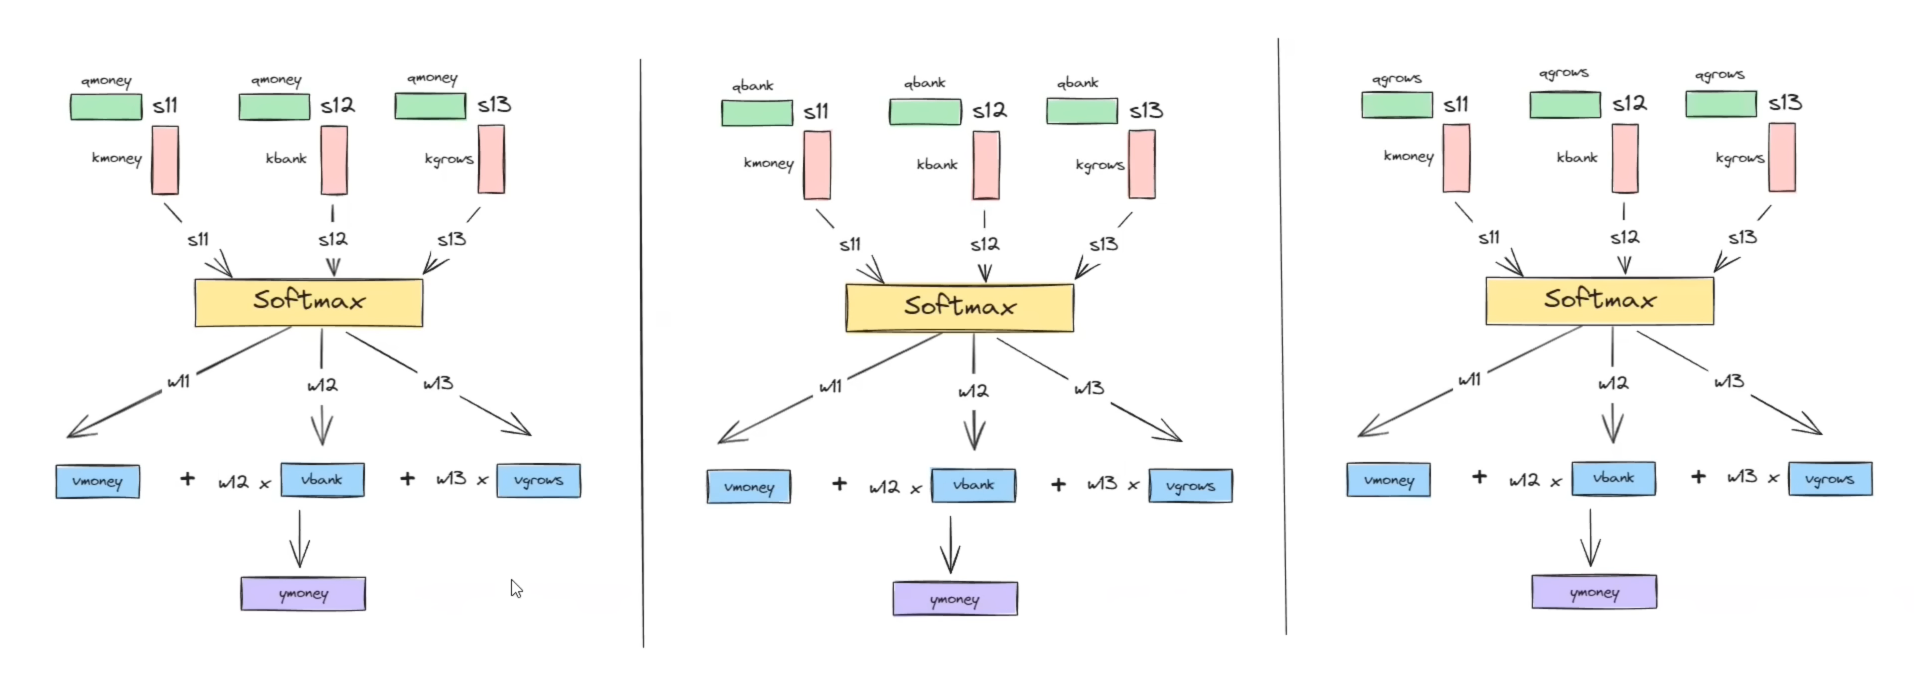

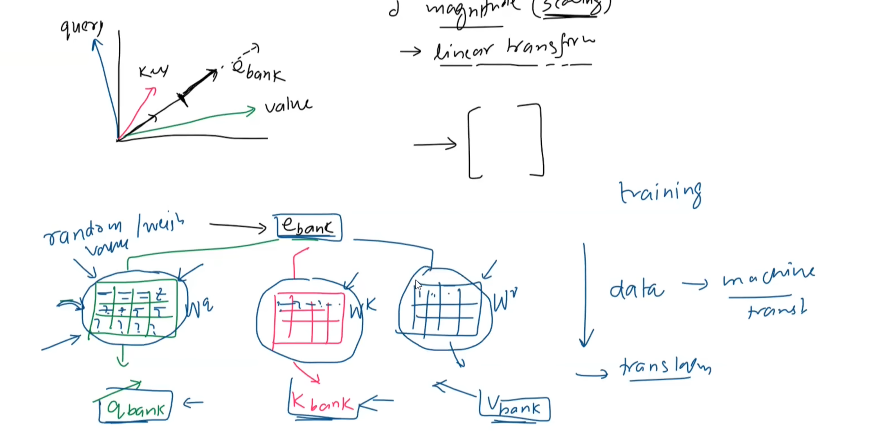

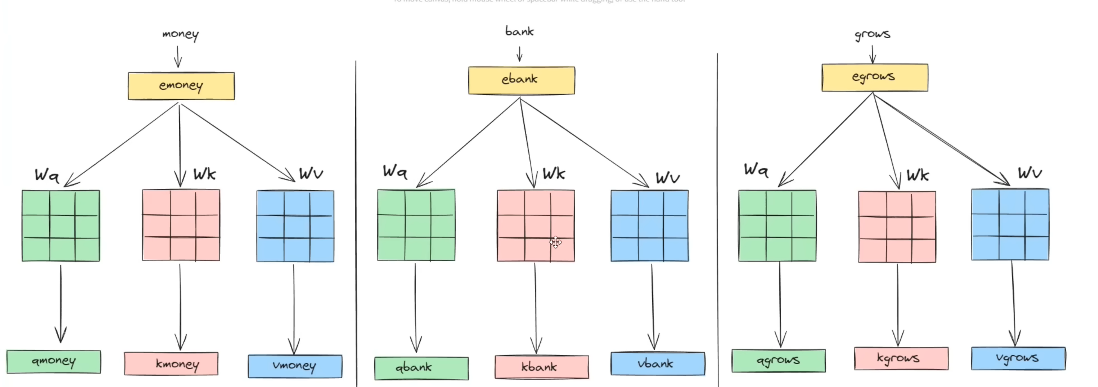

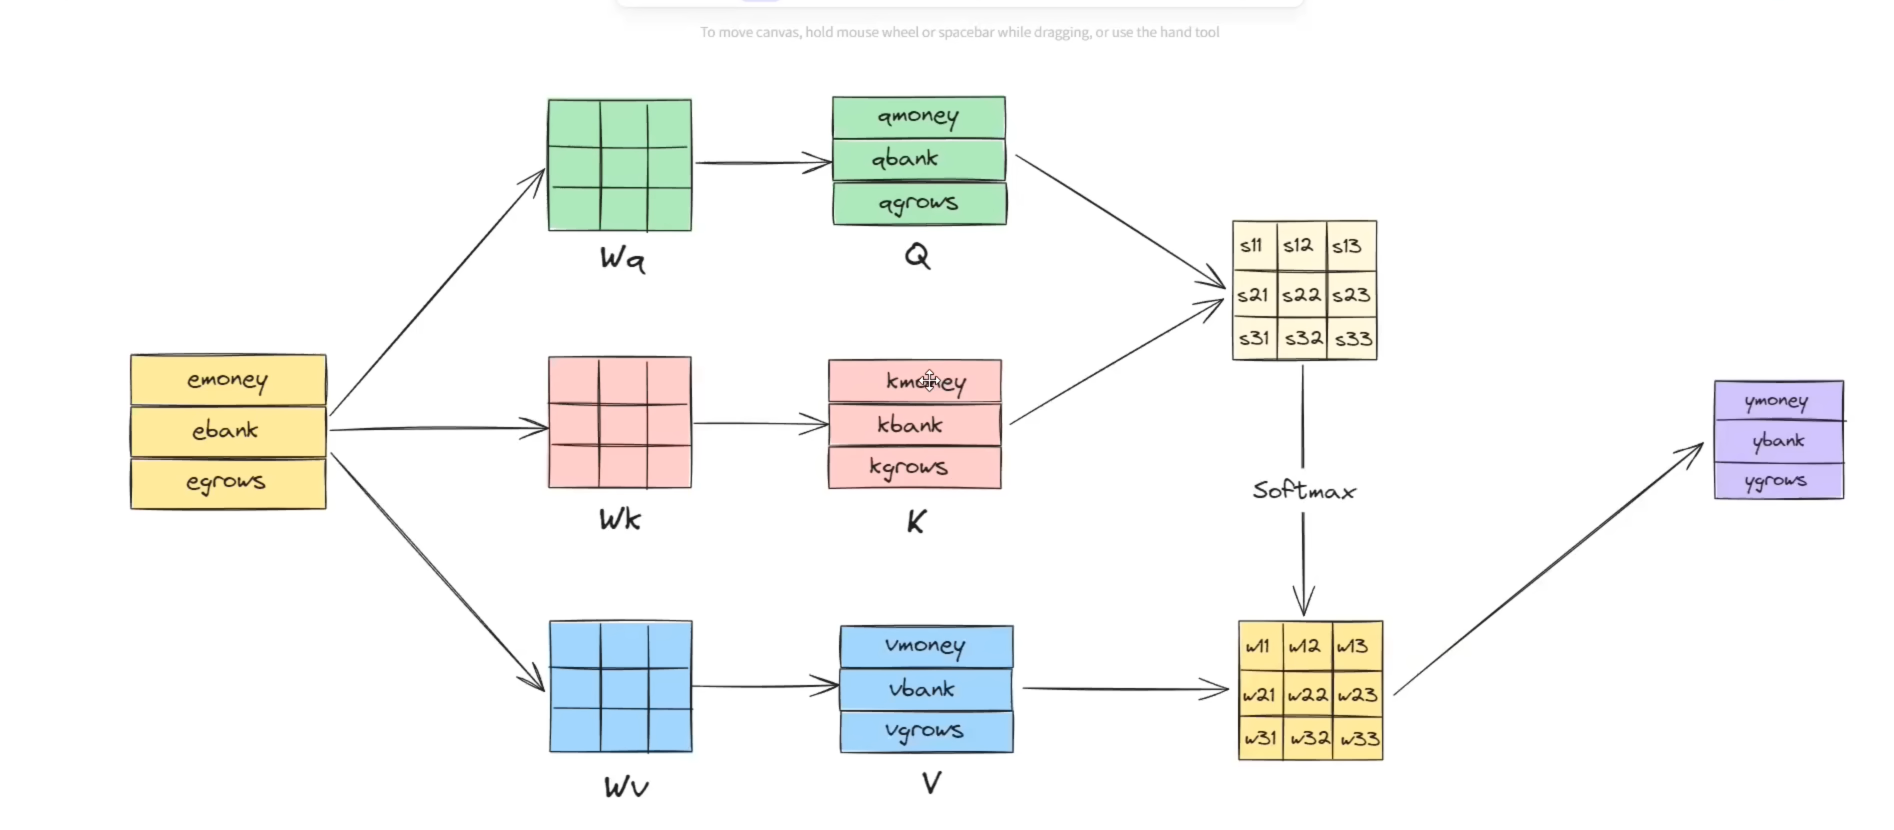



### 1. The Problem Self-Attention Solves: Limitations of Static Word Embeddings

Traditional Natural Language Processing (NLP) applications require machines to understand words by representing them as numbers. Techniques like One-Hot Encoding, Bag of Words, and **Word Embeddings** (e.g., Word2Vec, GloVe) are used for this.

*   **Semantic Meaning**: Word embeddings are particularly valuable because they can convert the **semantic meaning of words into numerical representations**.
*   **The "Bank" Problem (Static Nature)**: Despite their utility, a major drawback of early word embeddings is their **static nature**. This means that once trained, a word like "bank" will always have the exact same embedding, regardless of its context in a sentence.
    *   For example, in "money bank" (referring to a financial institution) and "river bank" (referring to the edge of a river), the word "bank" has different meanings. However, a static word embedding would assign the same numerical representation to "bank" in both sentences, leading to incorrect interpretations for subsequent NLP tasks.
*   **The Need for Contextual Embeddings**: To overcome this, there was a need for **contextual embeddings**, which are **dynamic** and change based on the word's usage and surrounding context in a sentence. Self-attention was developed precisely to solve this, acting as a way to convert static embeddings into dynamic, contextual ones.

### 2. The Initial Simple Self-Attention Model (First Principles Approach)

The video first explores a simplified, "first principles" approach to understanding how self-attention could be invented to generate contextual embeddings.

*   **Mechanism**:
    1.  **Static Embeddings**: Start by obtaining static word embeddings for each word in a sentence (e.g., "Humans love smartphones").
    2.  **Weighted Sum Representation**: The core idea is that the meaning of a word (e.g., "bank") is not just its individual meaning, but also its meaning in relation to other words in the sentence (e.g., "money" and "grows" in "Money bank grows"). A new, contextual embedding for a word is generated as a **weighted sum of all word embeddings in the sentence**.
    3.  **Similarity Calculation (Dot Product)**: The "weights" in this sum represent the **similarity** between the target word and every other word in the sentence (including itself). This similarity can be effectively calculated using the **dot product** of their respective embedding vectors. A higher dot product indicates greater similarity.
    4.  **Normalization (Softmax)**: The raw dot product scores (which can be any real number) are then normalized using a **Softmax function**. Softmax converts these scores into a probability distribution, ensuring that the weights for a given word's new embedding sum to one, making them easily interpretable (e.g., "bank" is 70% "bank", 20% "money", 10% "grows").
    5.  **Contextual Embedding Generation**: These Softmax-normalized weights are then multiplied by their corresponding word embeddings, and the results are summed up to produce the **new, dynamic, contextual word embedding**. This process is repeated for every word in the sentence.

*   **Key Advantage: Parallelization**:
    *   A significant insight of this approach is that the computation of new contextual embeddings for all words in a sentence can be performed **in parallel**.
    *   Using **linear algebra and matrix operations**, the entire process (calculating dot products, applying Softmax, and performing weighted sums) can be done efficiently in one go for all words. This parallelizability is a **major benefit**, allowing GPUs to be utilized for **very fast training**.

*   **Major Disadvantages of the Simple Model**:
    1.  **Loss of Sequential Information**: While parallel processing is fast, it inherently **loses information about the sequence or order of words** in the sentence.
    2.  **No Learning Parameters (General Embeddings Only)**: Crucially, this simple model **lacks any learning parameters** (weights and biases).
        *   Because there are no learnable parameters, the model cannot "learn" from data. It simply applies a fixed mathematical process.
        *   This means the contextual embeddings generated are **general contextual embeddings**, not **task-specific** ones.
        *   For complex NLP tasks like machine translation, general contextual embeddings can be insufficient. For example, "piece of cake" might be literally translated as "a piece of cake" rather than its idiomatic meaning "very easy task" if the model cannot learn from the translation data. Similarly, "break a leg" might be translated literally instead of as "good luck".
        *   Therefore, the need for **task-specific contextual embeddings** became apparent.

### 3. The Refined Self-Attention Model: Introducing Learning Parameters (Query, Key, Value)

The next step is to introduce learnable parameters into the self-attention mechanism to enable the generation of task-specific contextual embeddings.

*   **Where to Introduce Parameters?**: The mathematical operations (dot product, Softmax, dot product) have limited places for introducing weights. The most logical places are within the dot product calculations.
*   **The Roles of Word Embeddings (Query, Key, Value)**:
    *   Upon closer examination, each word embedding actually plays **three distinct roles** in the process of generating contextual embeddings:
        1.  **Query (Q)**: The embedding asking "how similar are you to me?".
        2.  **Key (K)**: The embedding being queried, responding "this is my content, evaluate my similarity".
        3.  **Value (V)**: The embedding providing its content for the final weighted sum.
    *   **Analogy**: This concept is like a computer science dictionary, where you **query** for a **key**, and if found, you get its **value**.
    *   **Critique of Using a Single Embedding**: The problem with the simple model was that the **same word embedding (E)** was performing all three roles (Q, K, V).
    *   **Separation of Concerns (Author Analogy)**: The presenter uses a detailed analogy of an author trying to find a spouse on a dating website to explain why having separate, specialized vectors for Query, Key, and Value is crucial:
        *   **Autobiography (Original Word Embedding)**: Contains all information about the author.
        *   **Search (Query Vector)**: The author needs a *specific, optimized* search query (e.g., "working professional from X state") to find suitable partners, not their entire autobiography.
        *   **Profile (Key Vector)**: The author needs a *concise, attractive, optimized* profile to present to others, highlighting the best aspects of their autobiography, not the whole book.
        *   **Match Conversation (Value Vector)**: Once a match is made, the author needs to present their personality's *best, relevant aspects* during conversation to foster the relationship, not unfiltered information that might scare someone away.
        *   **Conclusion**: Just as the autobiography is too general for searching, profiling, or conversation, a single word embedding is too general to optimally perform Query, Key, and Value roles. **Three separate, task-optimized vectors (Q, K, V) are needed from the original embedding**.

*   **Generating Query, Key, and Value Vectors**:
    1.  **Linear Transformation**: A new vector from an existing one can be generated through **linear transformation**, which involves **matrix multiplication**.
    2.  **Learnable Weight Matrices**: For each original word embedding (E), three distinct vectors are generated:
        *   **Query (Q) = E * Wq**
        *   **Key (K) = E * Wk**
        *   **Value (V) = E * Wv**
        Where **Wq, Wk, and Wv are learnable weight matrices**.
    3.  **Learning from Data**: These weight matrices are **initialized with random values**. During the training process, as the model processes data and makes predictions, **backpropagation adjusts the values within Wq, Wk, and Wv** to optimize them for the specific NLP task (e.g., machine translation data). This is how the model learns to generate task-specific Q, K, and V vectors from the general word embeddings.
    4.  **Shared Matrices**: Importantly, the **same Wq, Wk, and Wv matrices are used for *all* words** in the sentence, allowing for consistent learning across the entire input.

*   **Refined Self-Attention Mechanism (with Q, K, V)**:
    1.  For each word in the sentence, calculate its Query (Q), Key (K), and Value (V) vectors using the learnable Wq, Wk, and Wv matrices.
    2.  Calculate similarity scores by taking the **dot product of the target word's Query vector (Q)** with **all words' Key vectors (K)** in the sentence.
    3.  Apply **Softmax** to normalize these similarity scores into weights.
    4.  Compute the new contextual embedding as a **weighted sum of all words' Value vectors (V)**, using the Softmax-normalized weights.

*   **Parallelization Remains**: Just like the simple model, this refined model with Q, K, and V vectors can still be computed entirely **in parallel using matrix operations**, maintaining its efficiency for fast training.

In conclusion, the self-attention mechanism, as implemented in Transformers, effectively generates **task-specific contextual embeddings** by transforming original word embeddings into specialized Query, Key, and Value vectors through learnable linear transformations. This entire process is highly **parallelizable**, making it efficient for training large language models.

The self-attention mechanism, a core component of the Transformer architecture central to Generative AI, fundamentally aims to convert static word embeddings into dynamic, contextual embeddings. The video details its functioning through two main approaches: a simple "first principles" model and a refined model incorporating learnable parameters.

### 1. The Simple Self-Attention Model (First Principles Approach)

This initial approach illustrates the basic idea of generating contextual embeddings from static ones.

*   **Step 1: Obtain Static Word Embeddings**
    For each word in a sentence (e.g., "Humans love smartphones"), static word embeddings are generated using techniques like Word2Vec or GloVe. These embeddings capture the semantic meaning of words but are fixed regardless of context.
*   **Step 2: Calculate Similarity Scores (Dot Product)**
    To understand a word's meaning in context, its new contextual embedding is proposed as a weighted sum of all word embeddings in the sentence. The "weights" represent the **similarity** between the target word's embedding and every other word's embedding (including itself). This similarity is calculated using the **dot product** of their respective embedding vectors. For example, to calculate the new embedding for "bank," you would find the similarity between "bank" and "money," "bank" and "bank," and "bank" and "grows".
*   **Step 3: Normalize Similarity Scores (Softmax)**
    The raw dot product scores, which can be any real number, are then passed through a **Softmax function**. Softmax normalizes these scores into a probability distribution, ensuring that the weights sum to one. This makes them interpretable, for instance, indicating that "bank" is 70% "bank," 20% "money," and 10% "grows".
*   **Step 4: Generate New Contextual Embedding (Weighted Sum)**
    Finally, these Softmax-normalized weights are multiplied by their corresponding word embeddings, and the results are summed up to produce the **new, dynamic, contextual word embedding**. This process is repeated for every word in the sentence.

**Key Aspects & Limitations of the Simple Model:**
*   **Parallelization:** A significant advantage is that this entire process can be performed **in parallel** for all words in a sentence using linear algebra and matrix operations, allowing for very fast computation and utilization of GPUs.
*   **Loss of Sequential Information:** While parallel, this approach inherently **loses information about the order or sequence of words** in the sentence.
*   **No Learning Parameters:** This model **lacks any learnable parameters** (weights and biases), meaning it cannot "learn" from data. As a result, it generates **general contextual embeddings**, not **task-specific** ones, which can be insufficient for complex NLP tasks like machine translation where idiomatic expressions (e.g., "piece of cake" meaning "very easy task" instead of a literal "cake slice") require specific contextual understanding derived from training data.

### 2. The Refined Self-Attention Model (with Query, Key, Value)

To overcome the limitations of the simple model, particularly the absence of learning parameters and the inability to generate task-specific embeddings, the refined self-attention model introduces learnable weight matrices.

*   **Step 1: Generate Query (Q), Key (K), and Value (V) Vectors**
    The core insight is that each original word embedding plays three distinct roles:
    *   **Query (Q):** Asking "how similar are you to me?".
    *   **Key (K):** Being queried, providing its content for similarity evaluation.
    *   **Value (V):** Providing its content for the final weighted sum.
    Instead of using the same original embedding for all three roles, three **separate, specialized vectors** (Q, K, V) are generated from each original word embedding. This is done through **linear transformation**, which involves multiplying the original word embedding (E) by three distinct, **learnable weight matrices**:
    *   **Query (Q) = E * Wq**
    *   **Key (K) = E * Wk**
    *   **Value (V) = E * Wv**
    Where **Wq, Wk, and Wv are learnable weight matrices**. These matrices are initially random and are **updated through backpropagation** during training, allowing the model to learn and generate task-specific Q, K, and V vectors based on the data. Crucially, the **same Wq, Wk, and Wv matrices are used for all words** in the sentence.
*   **Step 2: Calculate Similarity Scores (Query-Key Dot Product)**
    Similar to the simple model, similarity scores are calculated, but now by taking the **dot product of the target word's Query vector (Q)** with **all words' Key vectors (K)** in the sentence.
*   **Step 3: Normalize Similarity Scores (Softmax)**
    The resulting similarity scores from the Query-Key dot products are then normalized using the **Softmax function** to obtain attention weights.
*   **Step 4: Generate New Contextual Embedding (Weighted Sum of Values)**
    Finally, the new contextual embedding for the target word is computed as a **weighted sum of all words' Value vectors (V)**, using the Softmax-normalized attention weights.

**Key Aspects of the Refined Model:**
*   **Task-Specific Embeddings:** By introducing learnable parameters (Wq, Wk, Wv), the model can now generate **task-specific contextual embeddings** that are optimized for the particular NLP task (e.g., machine translation or sentiment analysis) it is being trained on.
*   **Parallelization Maintained:** This refined model also fully leverages **parallel computation through matrix operations**, allowing for efficient and fast training on GPUs, even with a large number of words.